## Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Load Cleaned Data

In [12]:
df = pd.read_csv("data/cleaned_data.csv")

df.head()

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
# Separate Features and Target
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

In [14]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (455, 30)
Testing size: (114, 30)


In [16]:


# Convert Back to DataFrame
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

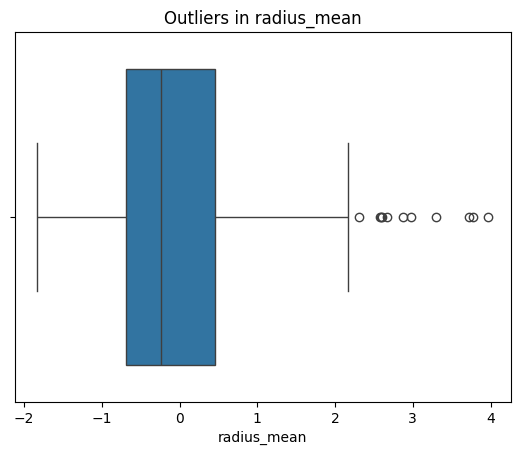

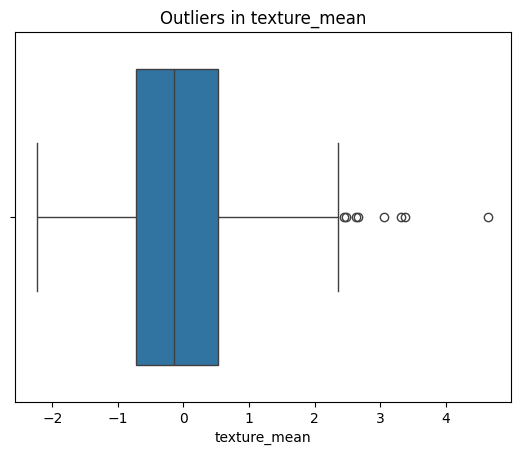

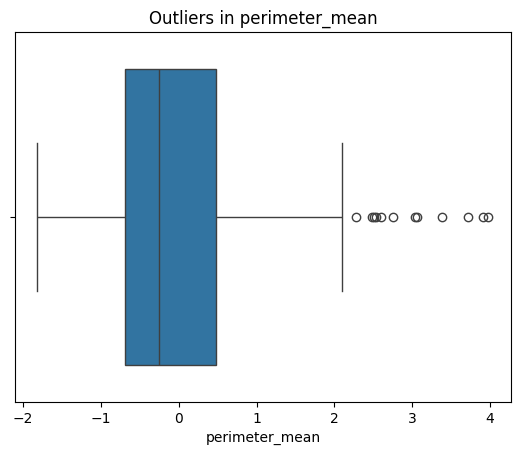

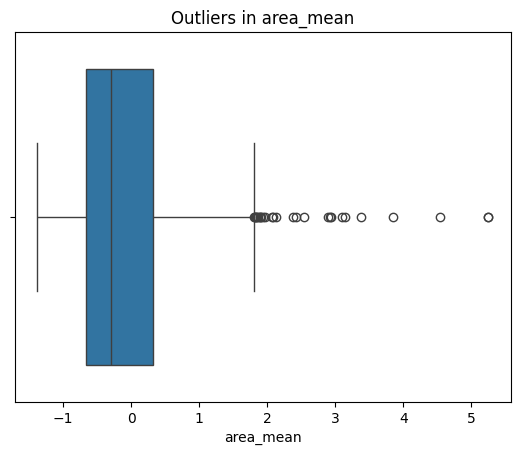

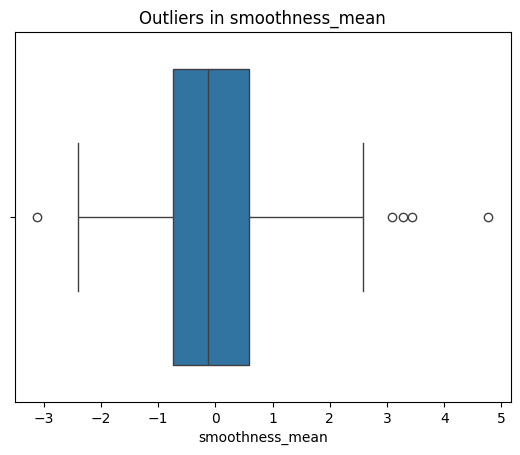

In [17]:
# Outlier Detection
for col in X.columns[:5]:  # check first few features
    plt.figure()
    sns.boxplot(x=X_train[col])
    plt.title(f"Outliers in {col}")
    plt.show()



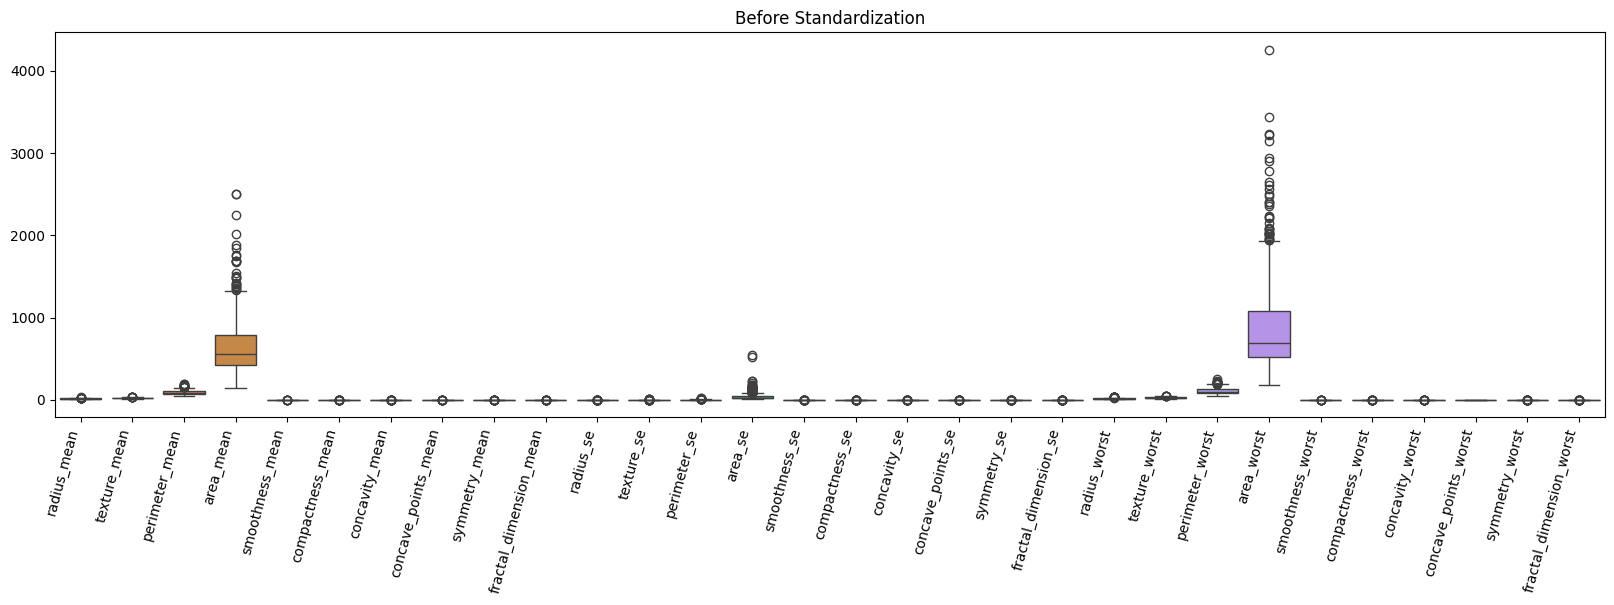

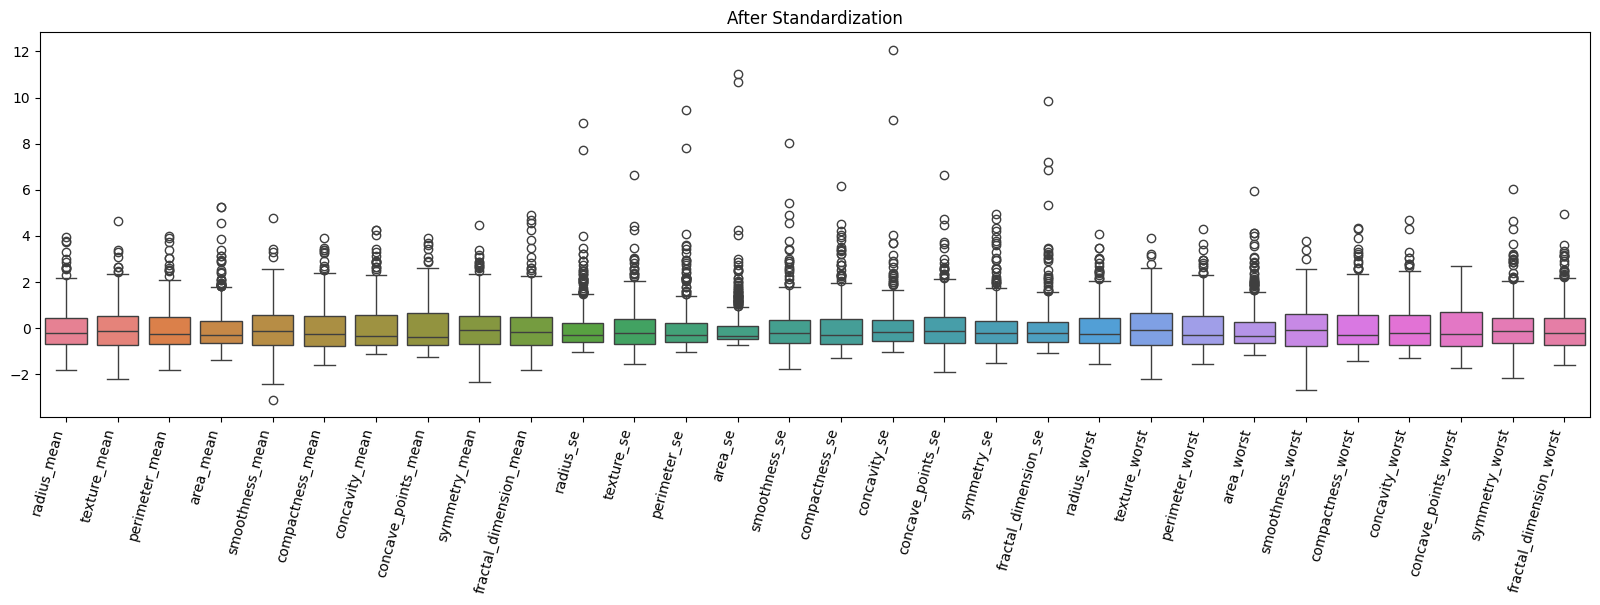

In [18]:
features_to_plot = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean'
]

# Feature ranges BEFORE standardization
plt.figure(figsize=(20,5))
sns.boxplot(data=X)
plt.title("Before Standardization")
plt.xticks(rotation=75, ha="right")
plt.show()

# Feature ranges AFTER standardization
plt.figure(figsize=(20,5))
sns.boxplot(data=X_train)
plt.title("After Standardization")
plt.xticks(rotation=75, ha="right")
plt.show()

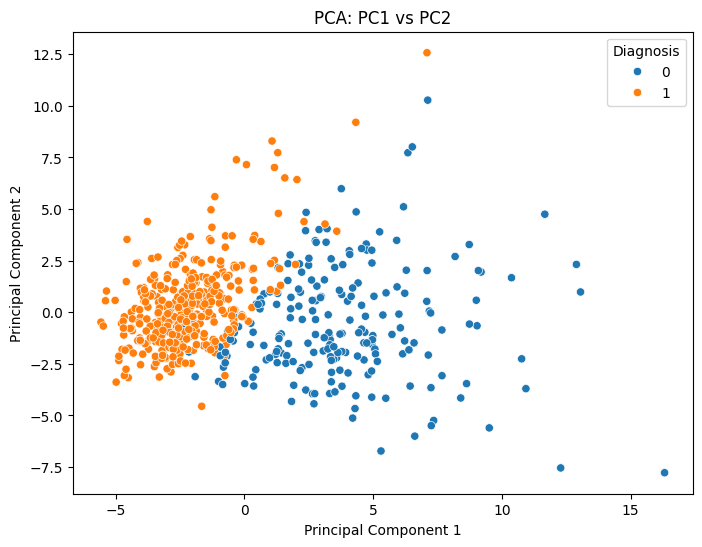

Explained Variance Ratio: 63.243207651559445


In [19]:
#  Apply PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#  Create a new DataFrame for PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Diagnosis'] = y

#  Plot PCA scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Diagnosis',
    data=pca_df,
    palette='tab10'
)

plt.title("PCA: PC1 vs PC2")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

#  Variance explained
print("Explained Variance Ratio:", sum(pca.explained_variance_ratio_)*100)

In [20]:
# Save Processed Data
X_train.to_csv("data/X_train_scaled.csv", index=False)
X_test.to_csv("data/X_test_scaled.csv", index=False)

y_train.to_csv("data/y_train.csv", index=False)
y_test.to_csv("data/y_test.csv", index=False)